# Markers

## Loading Packages

In [1]:
import warnings
warnings.filterwarnings('ignore')

import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd

import sys
sys.path.append(r'../../../')
from SpatialCOC.preprocess import  preprocessing
from SpatialCOC.utils import fix_seed, replace_extreme_values
fix_seed(2024)

## Loading Results

In [2]:
replicate = 2

## results of clusters
adata_analysis = sc.read_h5ad(f'../../Mouse_Spleen_Replicate{replicate}.h5ad')
print("the shape of adata_clusters:", np.shape(adata_analysis))

## oringinal expressions
adata_modality_1 = sc.read_h5ad(f'../../../Data/Mouse_Spleen_{replicate}/adata_RNA.h5ad')
adata_modality_2 = sc.read_h5ad(f'../../../Data/Mouse_Spleen_{replicate}/adata_ADT.h5ad')

adata_modality_1, adata_modality_2 = preprocessing(adata_modality_1, adata_modality_2, 'SPOTS')

the shape of adata_clusters: (2768, 0)
SPOTS data preprocessing have done!
Dimensions after preprocessed adata_modal_1: (2768, 3000)
Dimensions after preprocessing adata_modal_2: (2768, 21)


Marker orders:

replicate 1:    6, 2, 4, 1, 3, 5

replicate 2:    4, 2, 5, 3, 1, 6

Marker Genes:

replicate 1:    Igkc, mt-Co2, Hbb-bt, Marco, Hbb-bt, Ccl21a

replicate 2:    Hbb-bt, mt-Co2, Igha, mt-Co2, Ccl21a, Hbb-bt

re-order:

replicate 1:    Ccl21a, mt-Co2, Marco, Igkc, Hbb-bt, Hbb-bt

replicate 2:    mt-Co2, mt-Co2, Ccl21a, Igha, Hbb-bt, Hbb-bt

## Finding Marker Genes

In [3]:
adata_modality_1.obs['clusters'] = adata_analysis.obs['SpaKnit'].astype(str)
adata_modality_1.obs['clusters'] = adata_modality_1.obs['clusters'].astype('category')

In [4]:
# Now compute the dendrogram
sc.tl.dendrogram(adata_modality_1, groupby='clusters')

# Proceed with the rest of your analysis
sc.tl.rank_genes_groups(adata_modality_1, groupby='clusters', use_raw=False)

# Save marker genes
rank_genes = sc.get.rank_genes_groups_df(adata_modality_1, group=None)
rank_genes.to_excel(f'replicate{replicate}/marker_genes.xlsx', index=True)

         Falling back to preprocessing with `sc.pp.pca` and default params.


## Visualizing Marker Genes

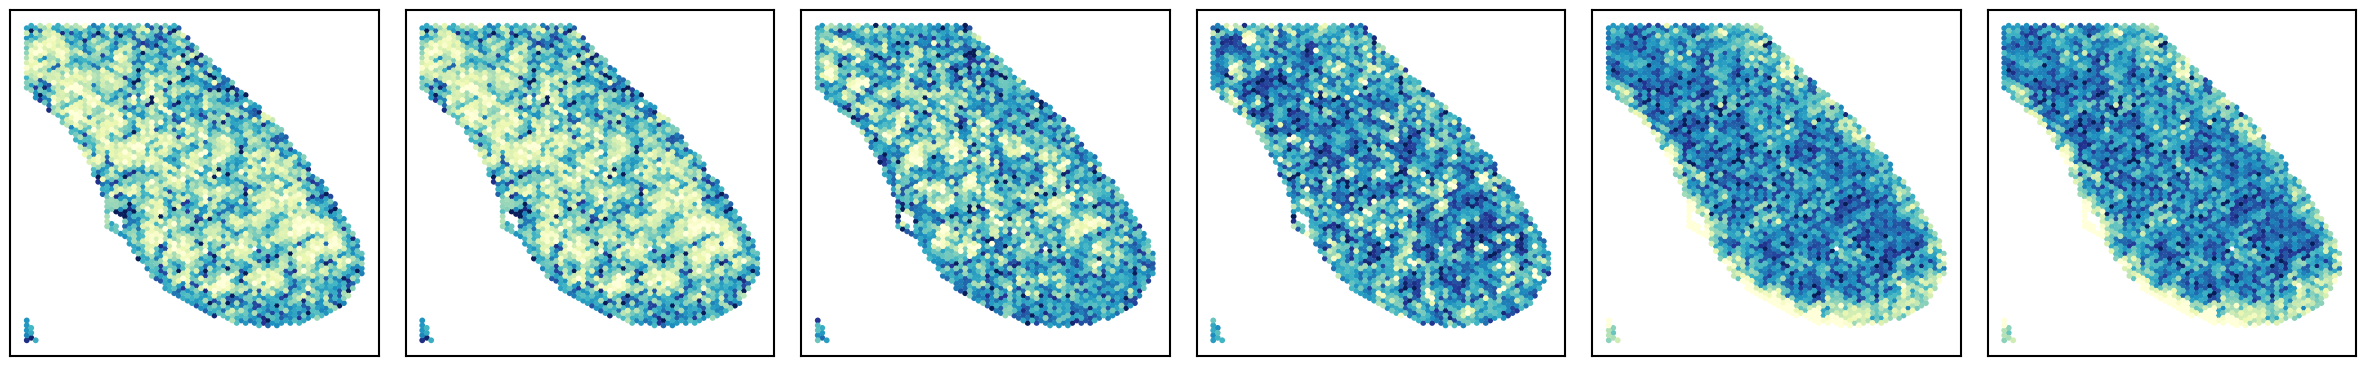

In [3]:
gene_lists = {
    1: ['Ccl21a', 'mt-Co2', 'Marco', 'Igkc', 'Hbb-bt', 'Hbb-bt'],
    2: ['mt-Co2', 'mt-Co2', 'Ccl21a', 'Igha', 'Hbb-bt', 'Hbb-bt']
}
# Replicate 1
gene_list = gene_lists[replicate]

num_genes = len(gene_list)  # Number of genes

plt.rcParams['font.size'] = 18
plt.rcParams['font.sans-serif'] = 'Arial'

# Create a row of subplots
fig, axs = plt.subplots(1, num_genes, figsize=(num_genes * 4, 4), squeeze=False)

# Iterate over the gene list and create a subplot for each gene
for i, gene in enumerate(gene_list):
    expression = adata_modality_1[:, gene].X.toarray().flatten()
    adata_modality_1[:, gene].X = replace_extreme_values(expression, n=0.02)
    sc.pl.embedding(adata_modality_1, basis='spatial', color=gene, ax=axs[0, i], s=70, colorbar_loc=None, show=False, cmap='YlGnBu_r')

    # Remove the spines of the subplot
    for spine in axs[0, i].spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)

    # Remove x and y axis labels
    axs[0, i].set_xlabel('')
    axs[0, i].set_ylabel('')
    axs[0, i].set_title('')
    if replicate == 2:
        axs[0, i].invert_xaxis()
        axs[0, i].invert_yaxis()
# Adjust the spacing between subplots
plt.subplots_adjust(wspace=0, hspace=0)

plt.tight_layout()

# plt.savefig(f"../Mouse_Spleen/replicate{replicate}/marker_genes.png", dpi=800)
# plt.savefig(f"../Mouse_Spleen/replicate{replicate}/marker_genes.eps")

## Finding Marker Proteins

Marker orders:

replicate 1:    6, 2, 4, 1, 3, 5

replicate 2:    4, 2, 5, 3, 1, 6

Marker Proteins:

replicate 1:    'CD68', 'IgD', 'F4_80', 'CD169_siglec', 'CD163', 'CD3'

replicate 2:    'F4_80', 'CD19', 'CD68', 'CD3', 'CD169_siglec', 'CD163'

re-order:  

replicate 1:    'CD3', 'IgD', 'CD169_siglec', 'CD68', 'F4_80', 'CD163'

replicate 2:    'CD3', 'CD19', 'CD169_siglec', 'CD68', 'F4_80', 'CD163'

In [223]:
adata_modality_2.obs['clusters'] = adata_analysis.obs['SpaKnit'].astype(str)
adata_modality_2.obs['clusters'] = adata_modality_2.obs['clusters'].astype('category')

In [224]:
# Now compute the dendrogram
sc.tl.dendrogram(adata_modality_2, groupby='clusters')

# Proceed with the rest of your analysis
sc.tl.rank_genes_groups(adata_modality_2, groupby='clusters', use_raw=False)

# Save marker genes
rank_genes = sc.get.rank_genes_groups_df(adata_modality_2, group=None)
rank_genes.to_excel(f'replicate{replicate}/marker_proteins.xlsx', index=True)

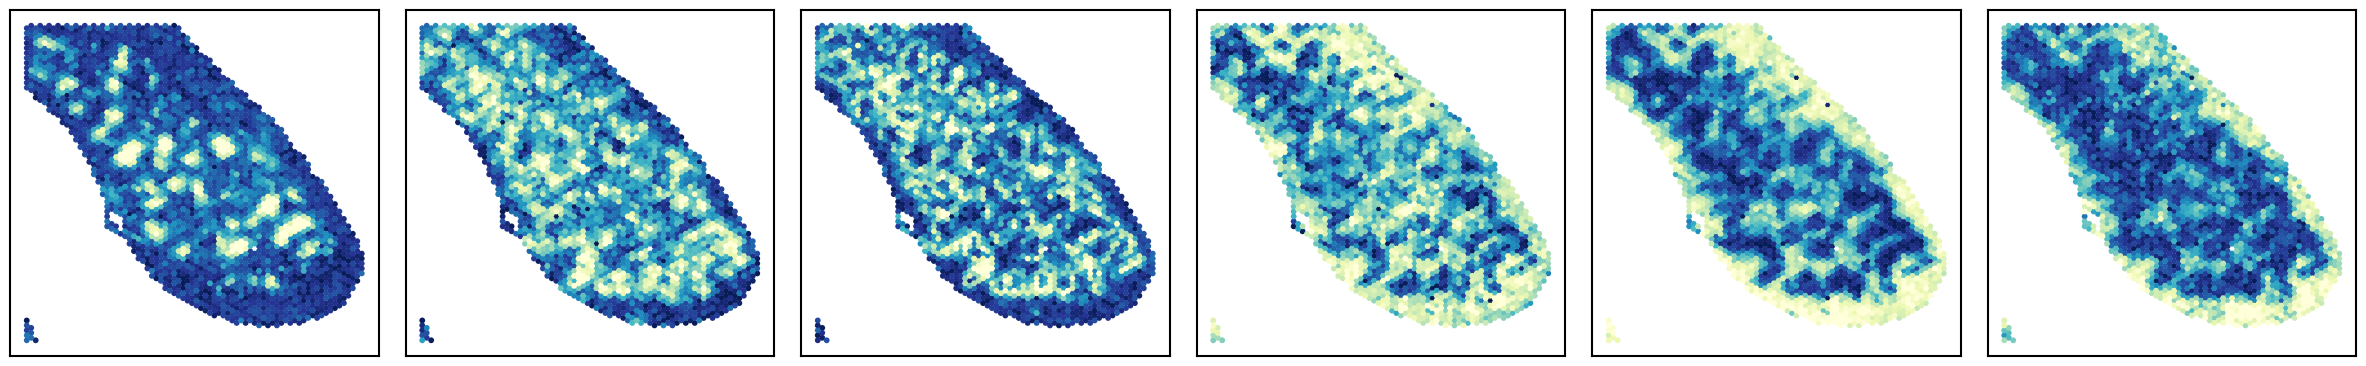

In [31]:
gene_lists = {
    1: ['CD3', 'IgD', 'CD169_siglec', 'CD68', 'F4_80', 'CD163'],
    2: ['CD3', 'CD19', 'CD169_siglec', 'CD68', 'F4_80', 'CD163']
}
# Replicate 1
gene_list = gene_lists[replicate]

num_genes = len(gene_list)  # Number of genes

plt.rcParams['font.size'] = 18
plt.rcParams['font.sans-serif'] = 'Arial'

# Create a row of subplots
fig, axs = plt.subplots(1, num_genes, figsize=(num_genes * 4, 4), squeeze=False)

# Iterate over the gene list and create a subplot for each gene
for i, gene in enumerate(gene_list):
    expression = adata_modality_2[:, gene].X.toarray().flatten()
    adata_modality_2[:, gene].X = replace_extreme_values(expression, n=0.02)
    sc.pl.embedding(adata_modality_2, basis='spatial', color=gene, ax=axs[0, i], s=70, colorbar_loc=None, show=False, cmap='YlGnBu_r')

    # Remove the spines of the subplot
    for spine in axs[0, i].spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)

    # Remove x and y axis labels
    axs[0, i].set_xlabel('')
    axs[0, i].set_ylabel('')
    axs[0, i].set_title('')
    if replicate == 2:
        axs[0, i].invert_xaxis()
        axs[0, i].invert_yaxis()
# Adjust the spacing between subplots
plt.subplots_adjust(wspace=0, hspace=0)

plt.tight_layout()

plt.savefig(f"../Mouse_Spleen/replicate{replicate}/marker_protein.png", dpi=800)
plt.savefig(f"../Mouse_Spleen/replicate{replicate}/marker_protein.eps")

In [8]:
import scanpy as sc
import pandas as pd
import numpy as np
from openpyxl import Workbook

def save_spatial_data_to_excel(replicate):

    adata_analysis = sc.read_h5ad(f'../../Mouse_Spleen_Replicate{replicate}.h5ad')
    print(f"Replicate {replicate} - shape of adata_clusters:", np.shape(adata_analysis))

    adata_modality_1 = sc.read_h5ad(f'../../../Data/Mouse_Spleen_{replicate}/adata_RNA.h5ad')
    adata_modality_2 = sc.read_h5ad(f'../../../Data/Mouse_Spleen_{replicate}/adata_ADT.h5ad')
    
    adata_modality_1, adata_modality_2 = preprocessing(adata_modality_1, adata_modality_2, 'SPOTS')

    gene_lists = {
        1: ['Ccl21a', 'mt-Co2', 'Marco', 'Igkc', 'Hbb-bt', 'Hbb-bt'],
        2: ['mt-Co2', 'mt-Co2', 'Ccl21a', 'Igha', 'Hbb-bt', 'Hbb-bt']
    }
    
    protein_lists = {
        1: ['CD3', 'IgD', 'CD169_siglec', 'CD68', 'F4_80', 'CD163'],
        2: ['CD3', 'CD19', 'CD169_siglec', 'CD68', 'F4_80', 'CD163']
    }

    gene_list = gene_lists[replicate]
    protein_list = protein_lists[replicate]

    data_dict = {}

    if 'spatial' in adata_modality_1.obsm:
        coords = adata_modality_1.obsm['spatial']
        data_dict['coord_x'] = coords[:, 0]
        data_dict['coord_y'] = coords[:, 1]
    else:
        print(f"Warning: No spatial coordinates found for replicate {replicate}")
        data_dict['coord_x'] = np.arange(adata_modality_1.n_obs)
        data_dict['coord_y'] = np.arange(adata_modality_1.n_obs)

    for i, gene in enumerate(gene_list):
        if gene in adata_modality_1.var_names:
            expression = adata_modality_1[:, gene].X
            # 转换为密集数组并展平
            if hasattr(expression, 'toarray'):
                expression = expression.toarray().flatten()
            else:
                expression = expression.flatten()
            
            # 直接存储原始表达值，不替换极值
            data_dict[f'Gene_{gene}'] = expression
        else:
            print(f"Warning: Gene {gene} not found in replicate {replicate}")
            data_dict[f'Gene_{gene}'] = np.zeros(adata_modality_1.n_obs)

    for i, protein in enumerate(protein_list):
        if protein in adata_modality_2.var_names:
            expression = adata_modality_2[:, protein].X

            if hasattr(expression, 'toarray'):
                expression = expression.toarray().flatten()
            else:
                expression = expression.flatten()

            data_dict[f'Protein_{protein}'] = expression
        else:
            print(f"Warning: Protein {protein} not found in replicate {replicate}")
            data_dict[f'Protein_{protein}'] = np.zeros(adata_modality_2.n_obs)

    df = pd.DataFrame(data_dict)
    
    return df

def main():

    all_data = {}

    for replicate in [1, 2]:
        print(f"\nProcessing replicate {replicate}...")
        df = save_spatial_data_to_excel(replicate)
        all_data[f'Replicate_{replicate}'] = df
        print(f"Replicate {replicate} data shape: {df.shape}")
        print(f"Columns: {list(df.columns)}")

    output_file = '../Mouse_Spleen/spatial_expression_data.xlsx'
    
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        for sheet_name, df in all_data.items():

            df.to_excel(writer, sheet_name=sheet_name, index=False)

            worksheet = writer.sheets[sheet_name]
            for column in df:
                column_width = max(df[column].astype(str).map(len).max(), len(column))
                col_idx = df.columns.get_loc(column)
                worksheet.column_dimensions[chr(65 + col_idx)].width = min(column_width + 2, 50)
    
    print(f"\n All Data saved: {output_file}")

if __name__ == "__main__":
    main()


Processing replicate 1...
Replicate 1 - shape of adata_clusters: (2568, 0)
SPOTS data preprocessing have done!
Dimensions after preprocessed adata_modal_1: (2568, 3000)
Dimensions after preprocessing adata_modal_2: (2568, 21)
Replicate 1 data shape: (2568, 13)
Columns: ['coord_x', 'coord_y', 'Gene_Ccl21a', 'Gene_mt-Co2', 'Gene_Marco', 'Gene_Igkc', 'Gene_Hbb-bt', 'Protein_CD3', 'Protein_IgD', 'Protein_CD169_siglec', 'Protein_CD68', 'Protein_F4_80', 'Protein_CD163']

Processing replicate 2...
Replicate 2 - shape of adata_clusters: (2768, 0)
SPOTS data preprocessing have done!
Dimensions after preprocessed adata_modal_1: (2768, 3000)
Dimensions after preprocessing adata_modal_2: (2768, 21)
Replicate 2 data shape: (2768, 12)
Columns: ['coord_x', 'coord_y', 'Gene_mt-Co2', 'Gene_Ccl21a', 'Gene_Igha', 'Gene_Hbb-bt', 'Protein_CD3', 'Protein_CD19', 'Protein_CD169_siglec', 'Protein_CD68', 'Protein_F4_80', 'Protein_CD163']

所有数据已保存到: ../Mouse_Spleen/spatial_expression_data.xlsx
